<a href="https://colab.research.google.com/github/MZGILL-1/AIML-Projects/blob/main/Low_Code_NLP_RAG_Project_Notebook_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

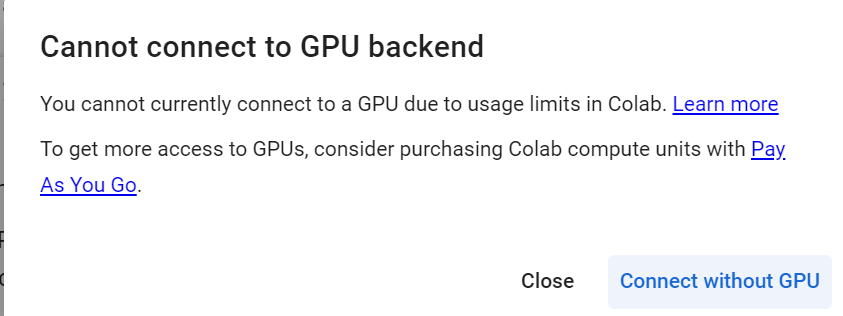

## Installing and Importing Necessary Libraries and Dependencies

In [1]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
# !CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 236.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 256.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 341.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 245.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.4 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.4

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# For installing the libraries & downloading models from HF Hub
!pip install huggingface_hub==0.23.2 pandas==1.5.3 tiktoken==0.6.0 pymupdf==1.25.1 langchain==0.1.1 langchain-community==0.0.13 chromadb==0.4.22 sentence-transformers==2.3.1 numpy==1.25.2 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [3]:
!pip install langchain langchain-community langchain-core langchain-text-splitters pypdf pymupdf chromadb sentence-transformers

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.6/326.6 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 119.4 MB/s eta 0:

In [4]:
#Libraries for downloading and loading the llm
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

## Question Answering using LLM

### Downloading and Loading the model

In [5]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [6]:
model_path = hf_hub_download(
    repo_id="TheBloke/Mistral-7B-Instruct-v0.2-GGUF", #Complete the code to mention the repo id
    filename="mistral-7b-instruct-v0.2.Q6_K.gguf" #Complete the code to mention the model name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [7]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path,
    n_ctx=4000,
    n_gpu_layers=38,
    n_batch=512
)

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [8]:
#uncomment the below snippet of code if the runtime is connected to CPU only.
#llm = Llama(
  # model_path=model_path,
 #  n_ctx=1024,
#)

### Response

In [9]:
def response(query,max_tokens=512,temperature=0,top_p=0.95,top_k=50):
    model_output = llm(
      prompt=query,
      max_tokens=max_tokens,
      temperature=temperature,
      top_p=top_p,
      top_k=top_k
    )

    return model_output['choices'][0]['text']

In [10]:
response("What treatment options are available for managing hypertension?")

"\n\nHypertension, or high blood pressure, is a common condition that can increase the risk of various health problems such as heart disease, stroke, and kidney damage. The good news is that there are several effective treatment options available to help manage hypertension and reduce the risk of complications. Here are some of the most commonly used treatments:\n\n1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, whole grains, and lean proteins; limiting sodium intake; getting regular physical activity; maintaining a healthy weight; and reducing stress through techniques such as meditation or deep breathing exercises.\n2. Medications: If lifestyle modifications alone are not enough to control hypertension, medications may be necessary. There are several classes of drugs used to treat hypertension, including diuretics, beta blockers, ACE inhibitors, calcium cha

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [11]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\n\nSepsis is a life-threatening condition that can arise from an infection, and it requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care unit:\n\n1. Early recognition: Recognize the signs and symptoms of sepsis early and initiate treatment as soon as possible. Sepsis can present with various clinical features, including fever or hypothermia, tachycardia or bradycardia, altered mental status, respiratory distress, and lactic acidosis.\n2. Resuscitation: Provide adequate fluid resuscitation to maintain adequate tissue perfusion. The goal is to achieve a mean arterial pressure (MAP) of at least 65 mmHg and a central venous oxygen saturation (ScvO2) of greater than 70%.\n3. Antibiotics: Administer broad-spectrum antibiotics as soon as possible based on the suspected source of infection and local microbiology data.\n4. Source control: Identify and address the source of infection, if possible. T

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [12]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to define the query #2
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ located in the lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but some common signs include:\n\n1. Abdominal pain: The pain may start as a mild discomfort around the navel or in the lower right abdomen, which then gradually moves to the right lower quadrant and becomes more severe over time. The pain may be constant or intermittent and is often worsened by movement, coughing, or deep breathing.\n2. Loss of appetite: People with appendicitis may lose their appetite due to abdominal pain and discomfort.\n3. Nausea and vomiting: Vomiting is a common symptom of appendicitis, especially in the later stages of the condition.\n4. Fever: A fever of 100.4°F (38°C) or higher may be present in some cases of appendicitis.\n5. Constipation or diarrhea: Both constipation and diarrhea can occur with appendicitis, depending on the location and

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [13]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to define the query #3
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nSudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, or eyelashes.\n\nThe exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications.\n\nThere are several treatments that have been shown to be effective in addressing sudden patchy hair loss:\n\n1. Corticosteroids: These are anti-inflammatory drugs that can help reduce inflammation and suppress the immune system's attack on the hair follicles. They can be applied topically or taken orally, depending on the severity of the condition.\n2. Minoxidil: This is a medication that has been shown to promote hair growth in some people with alopecia areata. It works by increa

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [14]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to define the query #4
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nA person who has sustained a physical injury to brain tissue, also known as a traumatic brain injury (TBI), may require various treatments depending on the severity and location of the injury. Here are some common treatments recommended for TBIs:\n\n1. Emergency care: The first priority is to ensure the person's airway is clear, they are breathing, and their heart is beating normally. In severe cases, emergency surgery may be required to remove hematomas or other obstructions.\n2. Medications: Depending on the symptoms, medications may be prescribed to manage conditions such as swelling, seizures, pain, or infections. For example, corticosteroids may be used to reduce brain swelling, and anticonvulsants may be given to prevent seizures.\n3. Rehabilitation: Rehabilitation is an essential part of the recovery process for TBI patients. Rehabilitation may include physical therapy to help with mobility and strength, occupational therapy to help with daily living skills, speech therapy 

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [15]:
user_input_2 = " What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to define the query #5
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nFirst and foremost, it is essential to ensure the safety of the injured person and any companions. If possible, try to keep the person as comfortable as possible by providing warmth, shelter, and fluids. Do not attempt to move them unless it is necessary for their safety or to prevent further injury.\n\nIf the fracture is visible and the leg appears misshapen or deformed, do not try to realign the bone yourself. Instead, immobilize the leg as best as possible using a splint or makeshift sling made from clothing or other available materials. Splinting the leg can help prevent further damage and provide some pain relief.\n\nOnce you have stabilized the fracture, assess the person's vital signs, including their breathing, pulse, and level of consciousness. If they are experiencing significant pain, difficulty breathing, or other symptoms that suggest a more severe injury, such as bleeding or numbness, seek medical help immediately.\n\nIf the person is stable and able to be moved, try

## Question Answering using LLM with Prompt Engineering

In [16]:
# Cell 15 — REPLACE existing system_prompt with this
system_prompt = """
You are a clinical reference assistant.

Format:
• Respond ONLY with bullet points (use the '•' bullet).
• Keep the entire answer ≤150 words.
• Use exactly these sections in order (each may have one or more bullets):
  Assessment
  Initial management
  Alternatives/Caveats
  When to escalate/consult

Rules:
• Do NOT invent numeric doses, volumes, timings, or page citations unless they are explicitly provided in the prompt.
• If information is insufficient in LLM-only mode, say: "Not enough information in LLM-only mode."

End with this exact line:
Citations: N/A (LLM-only)
"""

# (Optional helpers — add right below, still in Cell 15)
def build_prompt(question: str) -> str:
    return f"{system_prompt}\n\nQuestion: {question}"

def cap_150_words(text: str) -> str:
    words = text.split()
    return " ".join(words[:150]) if len(words) > 150 else text


### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [17]:
user_input = system_prompt+"\n"+ "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\n\nAssessment:\n• Monitor vital signs, respiratory status, and mental status\n• Check for signs of infection (fever, chills, wound infection, etc.)\n• Assess source of infection\n• Evaluate organ function (labs, imaging)\n• Consider septic shock if patient has persistent hypotension despite fluid resuscitation\n\nInitial management:\n• Administer oxygen as needed to maintain adequate saturation\n• Initiate intravenous fluids for volume resuscitation\n• Begin broad-spectrum antibiotics based on suspected infection source\n• Provide vasopressors if necessary for blood pressure support\n• Consider corticosteroids in cases of septic shock\n\nAlternatives/Caveats:\n• Early goal-directed therapy (EGDT) is an alternative approach to sepsis management, focusing on specific hemodynamic and oxygenation targets\n• Source control measures (e.g., surgical intervention, drainage) may be necessary for certain infections\n• Noninvasive positive pressure ventilation or mechanical ventilation may be r

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [18]:
user_input = system_prompt+"\n"+"What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAssessment:\n• Sudden pain in lower right abdomen, often starting around the navel and moving downward\n• Loss of appetite, nausea, and vomiting\n• Fever and chills\n• Abdominal swelling and tenderness\n• Pain worsens with movement or pressure on the abdomen\n\nInitial management:\n• NPO (nothing by mouth) and IV fluids for hydration\n• Antibiotics to prevent perforation and infection spread\n• Monitor vital signs, pain level, and bowel function\n\nAlternatives/Caveats:\n• Not enough information in LLM-only mode to determine if there are any alternatives or caveats.\n\nWhen to escalate/consult:\n• Severe abdominal pain that does not improve with medication\n• Signs of perforation, such as fever above 102°F (38.9°C), severe abdominal tenderness, or rebound tenderness\n• Inability to tolerate fluids or medications\n\nCitations: N/A (LLM-only)'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [19]:
user_input = system_prompt+"\n"+"What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAssessment:\n• Sudden patchy hair loss can be alarming but is often not a sign of a serious underlying condition.\n• Assess the size, shape, and number of bald spots.\n• Consider any recent stressors or trauma to the affected areas.\n• Look for signs of inflammation, redness, or scaling.\n\nInitial management:\n• Encourage good hair hygiene practices (gentle shampooing, avoiding harsh chemicals).\n• Provide reassurance and encourage patience as hair regrowth may take time.\n• Consider nutritional supplements like biotin or iron if deficiencies are suspected.\n\nAlternatives/Caveats:\n• Other causes of patchy hair loss include alopecia areata, lichen planopilaris, and traction alopecia.\n• Alopecia areata may require topical or systemic immunosuppressive therapy.\n• Traction alopecia can be prevented by avoiding tight hairstyles and using gentle hair care techniques.\n\nWhen to escalate/consult:\n• If the bald spots are large, increasing in size, or accompanied by other symptoms (e

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [20]:
user_input = system_prompt+"\n"+"What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nAssessment:\n• Determine the severity and location of the brain injury.\n• Assess the patient's level of consciousness (GCS score).\n• Evaluate for signs of intracranial hemorrhage or herniation.\n• Check vital signs, including heart rate, blood pressure, respiratory rate, and oxygen saturation.\n• Identify any associated injuries.\n\nInitial management:\n• Ensure airway patency and provide supplemental oxygen if needed.\n• Monitor and maintain adequate circulating volume.\n• Control seizures with benzodiazepines or other anticonvulsants as necessary.\n• Administer glucocorticoids to reduce edema and inflammation.\n• Provide supportive care, including nutrition and hydration.\n• Consider intubation and mechanical ventilation if the patient's condition deteriorates or they cannot protect their airway.\n\nAlternatives/Caveats:\n• Depending on the severity of the injury, other treatments may be considered, such as hyperventilation, hypothermia, or decompressive craniectomy.\n• In som

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [21]:
user_input = system_prompt+"\n"+" What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAssessment:\n• Assess for open fractures, neurovascular compromise, or other injuries.\n• Evaluate pain level, swelling, deformity, and mobility.\n• Determine the location and severity of the fracture.\n\nInitial management:\n• Apply a splint or immobilize the leg with a sling or brace to prevent further damage.\n• Provide analgesia as needed for pain control.\n• Encourage elevation of the injured limb to reduce swelling and promote healing.\n• Consider administering tetanus prophylaxis if the injury is contaminated.\n\nAlternatives/Caveats:\n• If the fracture is open or severely displaced, consider transporting the patient to a healthcare facility for further evaluation and potential surgical intervention.\n• For minor fractures, home care with follow-up appointments may be sufficient.\n\nWhen to escalate/consult:\n• Signs of infection (redness, warmth, increased pain, or drainage).\n• Persistent swelling or deformity.\n• Inability to bear weight on the affected leg.\n• Suspected

## Data Preparation for RAG

In [22]:
#Libraries for processing dataframes,text
import json,os
import tiktoken
import pandas as pd

#Libraries for Loading Data, Chunking, Embedding, and Vector Databases
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

### Loading the Data

In [23]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
manual_pdf_path = "/content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf" #Complete the code to define the file name

In [25]:
pdf_loader = PyMuPDFLoader(manual_pdf_path)

In [26]:
manual = pdf_loader.load()

### Data Overview

#### Checking the first 5 pages

In [27]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(manual[i].page_content,end="\n")

Page Number : 1
mzgill@gmail.com
VP87F3DYCL
meant for personal use by mzgill@gmai
shing the contents in part or full is liable
Page Number : 2
mzgill@gmail.com
VP87F3DYCL
This file is meant for personal use by mzgill@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 3
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    .......................................................................................................................................................................................................
2
Front Matter    ...........................................................................................................................................................................................
53
1 - Nutritiona

#### Checking the number of pages

In [28]:
len(manual)

4114

### Data Chunking

In [29]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000, #Complete the code to define the chunk size
    chunk_overlap=100 #Complete the code to define the chunk overlap
)

In [30]:
document_chunks = pdf_loader.load_and_split(text_splitter)

In [31]:
len(document_chunks)

4663

In [32]:
document_chunks[0].page_content

'mzgill@gmail.com\nVP87F3DYCL\nmeant for personal use by mzgill@gmai\nshing the contents in part or full is liable'

In [33]:
document_chunks[2].page_content

"Table of Contents\n1\nFront    ................................................................................................................................................................................................................\n1\nCover    .......................................................................................................................................................................................................\n2\nFront Matter    ...........................................................................................................................................................................................\n53\n1 - Nutritional Disorders    ...............................................................................................................................................................\n53\nChapter 1. Nutrition: General Considerations    ...........................................................................................

In [34]:
document_chunks[3].page_content

'491\nChapter 44. Foot & Ankle Disorders    .....................................................................................................................................\n502\nChapter 45. Tumors of Bones & Joints    ...............................................................................................................................\n510\n5 - Ear, Nose, Throat & Dental Disorders    ..................................................................................................................\n510\nChapter 46. Approach to the Patient With Ear Problems    ...........................................................................................\n523\nChapter 47. Hearing Loss    .........................................................................................................................................................\n535\nChapter 48. Inner Ear Disorders    ...................................................................................................

As expected, there are some overlaps

### Embedding

In [35]:
embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2") #Complete the code to define the model name

/tmp/ipython-input-2254781219.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2") #Complete the code to define the model name


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)

In [37]:
print("Dimension of the embedding vector ",len(embedding_1))
len(embedding_1)==len(embedding_2)

Dimension of the embedding vector  384


True

In [38]:
embedding_1,embedding_2

([-0.11048216372728348,
  0.06658510863780975,
  -0.0035706604830920696,
  -0.021740451455116272,
  0.08645594865083694,
  -0.04423629492521286,
  0.056537605822086334,
  0.06134122982621193,
  -0.006648072507232428,
  -0.030810236930847168,
  0.06065601855516434,
  -0.018529018387198448,
  0.01962869241833687,
  0.0019815347623080015,
  -0.05009656026959419,
  -0.06736331433057785,
  -0.036156926304101944,
  -0.006262683309614658,
  -0.08248479664325714,
  0.04411763325333595,
  -0.032009102404117584,
  -0.007104391697794199,
  -0.008255857974290848,
  0.01621781475841999,
  -0.01646438054740429,
  0.010575138963758945,
  -0.021262096241116524,
  0.06411373615264893,
  -0.00045258685713633895,
  -0.0557062104344368,
  0.01506903488188982,
  0.04094788804650307,
  0.016558915376663208,
  0.008425584062933922,
  0.07985944300889969,
  0.03997696563601494,
  -0.07830019295215607,
  -0.048818521201610565,
  -0.05234627425670624,
  -0.05445589870214462,
  -0.052355945110321045,
  -0.021205

### Vector Database

In [39]:
out_dir = 'medical_db'

if not os.path.exists(out_dir):
  os.makedirs(out_dir)

In [40]:
vectorstore = Chroma.from_documents(
    document_chunks, #Complete the code to pass the document chunks
    embedding_model, #Complete the code to pass the embedding model
    persist_directory=out_dir
)

In [41]:
vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)

/tmp/ipython-input-2756559696.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)


In [42]:
vectorstore.embeddings

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [43]:
vectorstore.similarity_search("What are the common symptoms and treatments for pulmonary embolism?",k=3) #Complete the code to pass a query and an appropriate k value

[Document(metadata={'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'trapped': '', 'page': 2079, 'creator': 'Atop CHM to PDF Converter', 'keywords': '', 'moddate': '2025-09-12T23:01:23+00:00', 'total_pages': 4114, 'subject': '', 'modDate': 'D:20250912230123Z', 'creationdate': '2012-06-15T05:44:40+00:00', 'creationDate': 'D:20120615054440Z', 'source': '/content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf', 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'format': 'PDF 1.7', 'file_path': '/content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf', 'author': ''}, page_content="Chapter 194. Pulmonary Embolism\nIntroduction\nPulmonary embolism (PE) is the occlusion of ≥ 1 pulmonary arteries by thrombi that originate\nelsewhere, typically in the large veins of the lower extremities or pelvis. Risk factors are\nconditions that impair venous return, conditions that cause endothelial injury or dysfunction,\nand underlying hypercoagulable st

### Retriever

In [44]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 3} #Complete the code to pass an appropriate k value
)

In [45]:
rel_docs = retriever.get_relevant_documents("What is the protocol for managing sepsis in a critical care unit?") #Complete the code to pass the query
rel_docs

/tmp/ipython-input-1679807008.py:1: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  rel_docs = retriever.get_relevant_documents("What is the protocol for managing sepsis in a critical care unit?") #Complete the code to pass the query


[Document(metadata={'keywords': '', 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'author': '', 'trapped': '', 'creationDate': 'D:20120615054440Z', 'creator': 'Atop CHM to PDF Converter', 'subject': '', 'page': 2400, 'creationdate': '2012-06-15T05:44:40+00:00', 'source': '/content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf', 'format': 'PDF 1.7', 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'total_pages': 4114, 'moddate': '2025-09-12T23:01:23+00:00', 'file_path': '/content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf', 'modDate': 'D:20250912230123Z'}, page_content="16 - Critical Care Medicine\nChapter 222. Approach to the Critically Ill Patient\nIntroduction\nCritical care medicine specializes in caring for the most seriously ill patients. These patients are best\ntreated in an ICU staffed by experienced personnel. Some hospitals maintain separate units for special\npopulations (eg, cardiac, surgical, neurologic, pediatric

In [46]:
model_output = llm(
      "What treatment options are available for managing hypertension?", #Complete the code to pass the query
      max_tokens=512, #Complete the code to pass the maximum number of tokens
      temperature=0, #Complete the code to pass the temperature
    )

Llama.generate: prefix-match hit


In [47]:
model_output['choices'][0]['text']

"\n\nHypertension, or high blood pressure, is a common condition that can increase the risk of various health problems such as heart disease, stroke, and kidney damage. The good news is that there are several effective treatment options available to help manage hypertension and reduce the risk of complications. Here are some of the most commonly used treatments:\n\n1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, whole grains, and lean proteins; limiting sodium intake; getting regular physical activity; maintaining a healthy weight; and reducing stress through techniques such as meditation or deep breathing exercises.\n2. Medications: If lifestyle modifications alone are not enough to control hypertension, medications may be necessary. There are several classes of drugs used to treat hypertension, including diuretics, beta blockers, ACE inhibitors, calcium cha

In [48]:
def preview_retrieval(docs, max_chars=600):
    for i, d in enumerate(docs, 1):
        src  = d.metadata.get("source", "unknown")
        page = d.metadata.get("page", d.metadata.get("page_number", "n/a"))
        print(f"\n=== Result {i} | source: {src} | page: {page} ===")
        print(d.page_content[:max_chars].strip(), "…")

preview_retrieval(rel_docs)



=== Result 1 | source: /content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf | page: 2400 ===
16 - Critical Care Medicine
Chapter 222. Approach to the Critically Ill Patient
Introduction
Critical care medicine specializes in caring for the most seriously ill patients. These patients are best
treated in an ICU staffed by experienced personnel. Some hospitals maintain separate units for special
populations (eg, cardiac, surgical, neurologic, pediatric, or neonatal patients). ICUs have a high
nurse:patient ratio to provide the necessary high intensity of service, including treatment and monitoring
of physiologic parameters.
Supportive care for the ICU patient includes provision of adequat …

=== Result 2 | source: /content/drive/MyDrive/Colab Notebooks/medical_diagnosis_manual.pdf | page: 1307 ===
shaking chills, persistent fever, altered sensorium, hypotension, and GI symptoms (abdominal pain,
nausea, vomiting, diarrhea) suggests sepsis or septic shock. Septic shock develo

The above response is somewhat generic and is solely based on the data the model was trained on, rather than the medical manual.  

Let's now provide our own context.

### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [49]:
qna_system_message = "AI Medical Assistant, answer the user's question based *only* on the following medical context."  #Complete the code to define the system message

In [50]:
qna_user_message_template = "Context: {context}\n\nQuestion: {question}" #Complete the code to define the user message

### Response Function

In [51]:
def generate_rag_response(user_input,k=3,max_tokens=512,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    prompt = qna_system_message + '\n' + user_message

    # Generate the response
    try:
        response = llm(
                  prompt=prompt,
                  max_tokens=max_tokens,
                  temperature=temperature,
                  top_p=top_p,
                  top_k=top_k
                  )

        # Extract and print the model's response
        response = response['choices'][0]['text'].strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [52]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
generate_rag_response(user_input)

Llama.generate: prefix-match hit


'Answer: The protocol for managing sepsis in a critical care unit includes early recognition and suspicion, obtaining cultures of blood and other appropriate specimens, initiating empiric antibiotics, adjusting antibiotics according to culture and susceptibility testing, surgically draining any abscesses, removing internal devices that are the suspected source of bacteria, and providing supportive care such as fluids, antipyretics, analgesics, and oxygen for patients with hypoxemia. Close monitoring is essential, and failure to improve should trigger further investigation for unusual organisms, resistance to antibiotics, empyema, coinfection or superinfection, obstructive endobronchial lesions, immunosuppression, metastatic focus of infection, or nonadherence to treatment.'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [53]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"Answer: The common symptoms of appendicitis include epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia; after a few hours, the pain shifts to the right lower quadrant. Pain increases with cough and motion. Classic signs are right lower quadrant direct and rebound tenderness located at McBurney's point (junction of the middle and outer thirds of the line joining the umbilicus to the anterior superior spine). Additional signs include pain felt in the right lower quadrant with palpation of the left lower quadrant (Rovsing sign), an increase in pain from passive extension of the right hip joint that stretches the iliopsoas muscle (psoas sign), or pain caused by passive internal rotation of the flexed thigh (obturator sign). Low-grade fever (rectal temperature 37.7 to 38.3° C [100 to 101° F]) is common, but these classic findings appear in less than 50% of patients. Many variations of symptoms and signs occur, and pain may not be localized or tenderness may b

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [54]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'Answer: Sudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects people with no obvious skin or systemic disorders. The scalp and beard are most frequently affected, but any hairy area may be involved. Hair loss may affect most or all of the body (alopecia universalis). Alopecia areata is thought to be an autoimmune disorder affecting genetically susceptible people exposed to unclear environmental triggers.\n\nThe treatment options for alopecia areata depend on the severity and extent of hair loss. For mild cases, topical treatments such as corticosteroids, minoxidil, or anthralin may be effective. Intralesional or systemic corticosteroids may be used for more severe cases. Immunotherapy with diphencyprone or squaric acid dibutylester can also be considered in severe cases. Psoralen plus ultraviolet A (PUVA) therapy is another option, but it carries a higher risk of side effects.\n\nThe cause of alopecia areata is not fully understood, but i

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [55]:
user_input_2 = " What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"Answer: The treatment for a person with a brain injury depends on the extent and location of the damage. For those in a persistent vegetative state lasting up to three months after the injury, there is a chance for recovery of normal neurologic function. However, almost none recover after six months. Speech therapists may help establish communication codes using eye blinks or movements. If cognitive function is intact, patients should make their own healthcare decisions if communication can be established. For brain death, which is the complete cessation of integrated brain function, there is no recovery. Diagnosis involves serial determination of clinical criteria and apnea testing, among other methods. Recovery from brain injury depends on the plasticity of the remaining cerebrum, which varies from person to person and is affected by age and general health. Plasticity is most prominent in the developing brain. There are specific syndromes associated with brain dysfunction, such as a

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [56]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'Answer: Based on the medical context provided, the following are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip:\n\n1. Assess the severity of the injury: Check for signs of open wounds, deformities, or impaired circulation in the affected limb. If there is significant bleeding, swelling, or numbness, seek immediate medical attention as these could indicate a more serious injury.\n2. Immobilize the injured leg: Use a splint or sling to prevent further injury and decrease pain. Splinting also helps prevent fat embolism in long-bone fractures.\n3. Treat for shock: If the person is experiencing symptoms of hemorrhagic shock, such as rapid heartbeat, low blood pressure, cold and clammy skin, or confusion, administer first aid measures like lying them down with their legs elevated above the heart level to improve circulation.\n4. Pain management: Administer pain medication, typically opioids, to help manage the discomfort associat

### Fine-tuning

New Code Changes and Parameter Fine Tuning

In [57]:
import numpy as np
from langchain.retrievers import ParentDocumentRetriever
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.storage import InMemoryStore
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings

# New, structured system prompt
structured_system_prompt = """
You are a clinical reference assistant.

Format:
• Respond ONLY with bullet points (use the '•' bullet).
• Keep the entire answer ≤150 words.
• Use exactly these sections in order (each may have one or more bullets):
  Assessment
  Initial management
  Alternatives/Caveats
  When to escalate/consult

Rules:
• Use only the provided context; do NOT invent numeric doses, volumes, timings, or page citations unless they are explicitly provided in the context.
• If information is insufficient in RAG mode, say: "Not enough evidence in RAG mode."

End with a citations line at the bottom.
"""

# The following two variables are assumed to be defined in the main notebook section.
# qna_user_message_template = "Context: {context}\n\nQuestion: {question}"
# vectorstore = Chroma(...)

In [58]:
def generate_rag_response_with_improvements(user_input, k=8, fetch_k=40, temperature=0, lambda_mult=0.5):
    global qna_user_message_template, structured_system_prompt

    # Define a character limit for the context to prevent exceeding the token window.
    # A character limit is a simpler, more reliable way to manage size than a
    # token count for this use case, as token counting is model-specific.
    context_char_limit = 3000  # A safe number to leave room for prompts and response

    # Upgrade the Retriever to MMR
    retriever_mmr = vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": k, "fetch_k": fetch_k, "lambda_mult": lambda_mult}
    )

    # Retrieve a large number of documents to be filtered
    relevant_document_chunks = retriever_mmr.get_relevant_documents(query=user_input)

    # Evidence Gate (Safety)
    if len(relevant_document_chunks) < 2:
        return "Not enough evidence in RAG mode."

    # Tighten Context Assembly and Surface Citations by character limit
    context_pages = {}
    context_for_query = ""

    for doc in relevant_document_chunks:
        doc_content = doc.page_content
        if len(context_for_query) + len(doc_content) + 2 <= context_char_limit:
            context_for_query += doc_content + "\n\n"
            page_number = doc.metadata.get('page')
            if page_number:
                context_pages[page_number] = doc.metadata.get('source')
        else:
            break

    unique_pages = sorted(list(context_pages.keys()))
    citations = "Citations: " + ", ".join([f"Merck Manual, p. {page}" for page in unique_pages])

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)
    prompt = structured_system_prompt + '\n' + user_message

    # Generate the response with stable parameters
    try:
        response = llm(
            prompt=prompt,
            max_tokens=512,
            temperature=temperature,
            top_p=0.95,
            top_k=50
        )
        response_text = response['choices'][0]['text'].strip()
        response_with_citations = response_text + "\n" + citations
    except Exception as e:
        response_with_citations = f'Sorry, I encountered the following error: \n {e}'

    return response_with_citations

In [59]:
user_input_1 = "What is the protocol for managing sepsis in a critical care unit?"
print(generate_rag_response_with_improvements(user_input_1))

Llama.generate: prefix-match hit


Answer:

Assessment:
• Monitor vital signs, respiratory status, and mental status frequently
• Check for signs of infection (fever, chills, leukocytosis)
• Assess source of infection
• Evaluate organ function (e.g., urine output, liver enzymes, coagulation parameters)

Initial management:
• Administer broad-spectrum antibiotics based on suspected infection site and microbiology results
• Provide fluid resuscitation to maintain adequate tissue perfusion
• Initiate vasopressors if needed for hypotension
• Provide oxygen therapy as needed for respiratory failure
• Consider early goal-directed therapy (EGDT) or sequential organ failure assessment (SOFA) protocols

Alternatives/Caveats:
• In some cases, steroids or antifungal agents may be considered based on the underlying infection and patient response
• Noninvasive hemodynamic monitoring (e.g., pulse pressure variation, stroke volume variation) can help guide fluid resuscitation
• Early consultation with an infectious disease specialist 

In [60]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"
print(generate_rag_response_with_improvements(user_input_2))

Llama.generate: prefix-match hit


Assessment:
• Sudden onset of pain, usually in the lower right abdomen
• Nausea and vomiting
• Loss of appetite
• Fever
• Abdominal swelling and tenderness
• Pain worsens with movement or pressure on the abdomen

Initial management:
• Encourage rest and fluids
• Administer analgesics for pain relief
• Consider antibiotics to prevent complications, but they are not a substitute for surgery

Alternatives/Caveats:
• Appendicitis cannot be cured with medicine alone. Surgery is the only effective treatment.
• If appendicitis ruptures before surgery, it can lead to peritonitis, which requires more extensive surgical intervention and longer recovery time.

When to escalate/consult:
• Severe abdominal pain that does not improve with rest or medication
• Fever above 38°C (100.4°F)
• Vomiting multiple times in a row
• Signs of peritonitis, such as rebound tenderness, guarding, or rigidity

References:
• American College of Surgeons. (2016). Acute appendicitis: Clinical presentation and diagnosis

In [61]:
user_input_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
print(generate_rag_response_with_improvements(user_input_3))

Llama.generate: prefix-match hit


Assessment:
• Sudden patchy hair loss can be caused by various factors including stress, hormonal imbalances, autoimmune conditions (such as alopecia areata), infections, or nutritional deficiencies.
• Assess for any recent stressors, changes in medication, or family history of hair loss.
• Observe the distribution and appearance of the bald spots.
• Consider performing a scalp biopsy to rule out underlying conditions such as fungal infections or autoimmune diseases.

Initial management:
• Encourage good nutrition and hygiene practices, including a balanced diet rich in iron, zinc, and vitamin B12, and regular shampooing with a gentle formula.
• Consider topical treatments such as minoxidil or corticosteroids for alopecia areata.
• For stress-related hair loss, recommend relaxation techniques like meditation, deep breathing exercises, or progressive muscle relaxation.

Alternatives/Caveats:
• Other potential causes of patchy hair loss include traction alopecia (due to hairstyles), telo

In [62]:
user_input_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
print(generate_rag_response_with_improvements(user_input_4))

Llama.generate: prefix-match hit


If the vegetative state lasts for more than 3 months but less than 6 months, what interventions can be made to help recover normal neurologic function?

Assessment:
• Assess the severity and extent of the injury using Glasgow Coma Scale (GCS) or other appropriate tools.
• Monitor vital signs, level of consciousness, and neurological status regularly.
• Evaluate for potential complications such as infections, seizures, or hydrocephalus.

Initial management:
• Provide supportive care including maintaining adequate oxygenation, hydration, nutrition, and temperature regulation.
• Manage any life-threatening conditions resulting from the injury.
• Consider early rehabilitation to prevent complications and promote functional recovery.

Alternatives/Caveats:
• There is no proven effective medical treatment to reverse brain damage caused by trauma.
• Some studies suggest that therapeutic hypothermia, deep brain stimulation, or hyperbaric oxygen therapy may have potential benefits in certain ca

In [63]:
user_input_5 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
print(generate_rag_response_with_improvements(user_input_5))

Llama.generate: prefix-match hit


Assessment:
• Assess for signs of shock (cool, clammy skin, rapid heartbeat, weak pulse)
• Check for open wounds or deformity in the affected leg
• Evaluate pain level and mobility

Initial management:
• Immobilize the fracture with a splint or sling
• Apply ice to reduce swelling and pain
• Provide analgesics as needed (acetaminophen, ibuprofen)
• Elevate the leg above heart level to minimize swelling
• Encourage hydration and proper nutrition

Alternatives/Caveats:
• If the fracture is open or severely displaced, seek medical attention immediately
• For severe pain or inability to bear weight, consider narcotic analgesics (opioids)
• Consider using crutches or a walker for mobility assistance

When to escalate/consult:
• If signs of infection develop (redness, warmth, increased pain, fever)
• If there is no improvement in symptoms after several days
• If the person experiences difficulty breathing or chest pain

Citations:
1. American Academy of Orthopaedic Surgeons. (2021). Fracture

Old Code, Now Commented to Avoid Running

#### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [64]:
#user_input = "What is the protocol for managing sepsis in a critical care unit?"
#generate_rag_response(user_input,temperature=0.5)

#### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [65]:
#user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
#generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

#### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [66]:
#user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
#generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

#### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [67]:
#user_input_2 = " What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
#generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

#### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [68]:
#user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
#generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

## Output Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation.

- We are using the same Mistral model for evaluation, so basically here the llm is rating itself on how well he has performed in the task.

In [69]:
groundedness_rater_system_message = "You are an evaluator. Your task is to assess if the given answer is grounded in the provided context. Respond with 'Yes' if the answer is fully supported by the context, and 'No' otherwise." #Complete the code to define the prompt to evaluate groundedness

In [70]:
relevance_rater_system_message = "You are an evaluator. Your task is to assess if the provided context is relevant to the user's question. Respond with 'Yes' if the context is relevant, and 'No' otherwise." #Complete the code to define the prompt to evaluate relevance

In [71]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [72]:
def generate_ground_relevance_response(user_input,k=3,max_tokens=512,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=3)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)

    # Combine user_prompt and system_message to create the prompt
    prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_input)}
                [/INST]"""

    response = llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    answer =  response["choices"][0]["text"]

    # Combine user_prompt and system_message to create the prompt
    groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    # Combine user_prompt and system_message to create the prompt
    relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    response_1 = llm(
            prompt=groundedness_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    response_2 = llm(
            prompt=relevance_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    return response_1['choices'][0]['text'],response_2['choices'][0]['text']

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [73]:
ground,rel = generate_ground_relevance_response(user_input="What is the protocol for managing sepsis in a critical care unit?",max_tokens=370)

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Yes, the answer is fully supported by the context. The context discusses various aspects of critical care medicine, including patient monitoring, blood tests, and treatment of infections such as sepsis. The answer summarizes the steps for managing sepsis in a critical care unit, which aligns with the information provided in the context about diagnosing and treating bacteremia, sepsis, or septic shock.

 Yes, the context is relevant as it discusses various aspects of critical care medicine, including patient monitoring, blood tests, and treatment approaches for critically ill patients, which includes sepsis management. The text mentions that sepsis is a potential complication in ICU patients and provides information on its diagnosis and treatment, such as obtaining cultures, administering antibiotics, and supportive care.


### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [74]:
ground,rel = generate_ground_relevance_response(user_input="What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?",max_tokens=370) #Complete the code to pass the query #2 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Yes, the answer is fully supported by the context provided. The context describes the symptoms and signs of appendicitis, mentions that treatment involves surgical removal of the appendix, and discusses various complications and potential treatments if surgery is not possible or if a large inflammatory mass is present. The answer summarizes this information accurately.

 Yes, the context is relevant to the user's question as it provides detailed information about the symptoms and signs of appendicitis, as well as its diagnosis and treatment. The context also mentions that appendicitis cannot be cured via medicine alone and that surgical removal is the standard treatment.


### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [75]:
ground,rel = generate_ground_relevance_response(user_input="What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?",max_tokens=370) #Complete the code to pass the query #3 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Yes, based on the context provided, alopecia areata is the condition that fits the description of sudden patchy hair loss. The text discusses various treatments for alopecia areata and mentions it as a condition characterized by sudden, patchy hair loss with no obvious skin or systemic disorder.

 Yes, the context is relevant to the user's question as it provides information about alopecia areata, which is a condition characterized by sudden patchy hair loss, and discusses various treatment options for this condition, as well as possible causes.


### Query 4: What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [76]:
ground,rel = generate_ground_relevance_response(user_input="What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?",max_tokens=370) #Complete the code to pass the query #4 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Based on the context provided, there is no explicit mention of treatments for a person with a brain injury. The text discusses some general information about diagnosing and prognosticating brain injuries, as well as the concept of brain death. Therefore, I would answer 'No' to the question, as the context does not fully support the claim that specific treatments are recommended for a person with a brain injury. However, it is important to note that individual treatment plans will depend on the specific nature and extent of the injury, as well as the patient's age and overall health. Consulting a healthcare professional for personalized advice is strongly recommended.

 Based on the context provided, there is no clear answer to what treatments are recommended for a person with a brain injury. The text discusses some general information about diagnosing and prognosticating brain injuries but does not mention specific treatments. It's important to note that individual treatment plans wil

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [77]:
ground,rel = generate_ground_relevance_response(user_input="What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?",max_tokens=370) #Complete the code to pass the query #5 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Yes, the answer is fully supported by the context provided. The context discusses various precautions and treatments for injuries sustained during hiking, including fractures. The answer covers immobilization with splinting or casting, RICE protocol, pain management, and the possibility of surgical intervention for severe injuries. These topics are all addressed in the context.

 Yes, the context is relevant to the user's question as it provides information on necessary precautions and treatment steps for a person who has fractured their leg, including immobilization techniques, RICE protocol, and pain management options. It also mentions the importance of assessing the severity of the injury and seeking emergency medical help if necessary.


## Actionable Insights and Business Recommendations


*   
*  
*



<font size=6 color='blue'>Power Ahead</font>
___